Import all libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import torch
from tqdm import tqdm
import time
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,log_loss,jaccard_score,roc_auc_score,classification_report,confusion_matrix
from torch.utils.data import Dataset, DataLoader
!pip install emoji
import emoji
import re
from sklearn.preprocessing import LabelEncoder

Read datasets

In [5]:
train_data = pd.read_csv('train.csv')
val_data = pd.read_csv('validation.csv')
test_data = pd.read_csv('test.csv')

Visualization of Label Distribution in Train Dataset

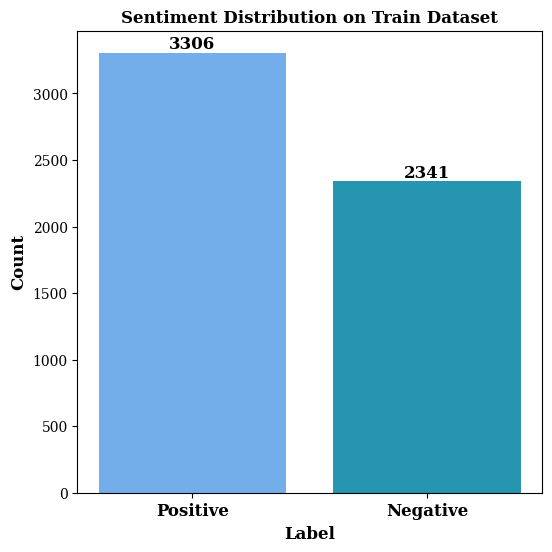

In [6]:
label_counts = train_data['sentiment'].value_counts()

# Define custom colors for the bars
custom_colors = ['#73aeea', '#2595b0']

# Define custom font dictionary for title and labels
font = {'family': 'Serif', 'weight': 'bold', 'size': 12}

plt.figure(figsize=(6, 6))

# Create bar plot with grid
bars = plt.bar(label_counts.index, label_counts.values, color=custom_colors)

# Set title and axis labels using custom fontdict
plt.title('Sentiment Distribution on Train Dataset', fontdict=font)
plt.xlabel('Label', fontdict=font)
plt.ylabel('Count', fontdict=font)

# Set custom font for ticks on both x and y axes
plt.xticks(label_counts.index, label_counts.index, fontdict=font)
plt.yticks(fontname='Serif', fontsize=10)

# Adding annotations (count values) on top of each bar
for bar, count in zip(bars, label_counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(count),
             ha='center', va='bottom', fontdict=font)

plt.show()

Visualization of Label Distribution in Validation Dataset

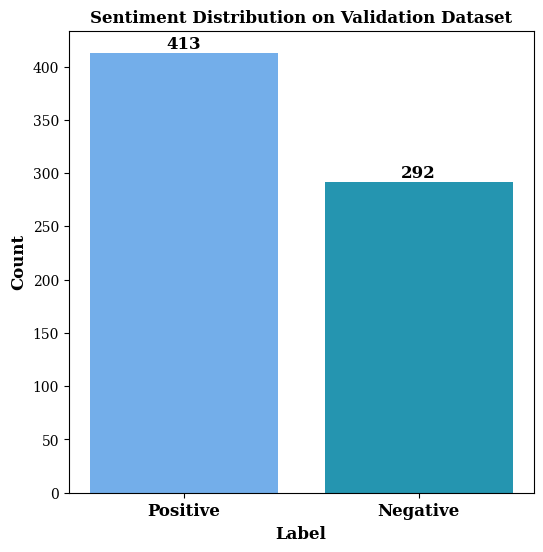

In [7]:
label_counts = val_data['sentiment'].value_counts()

# Define custom colors for the bars
custom_colors = ['#73aeea', '#2595b0']

# Define custom font dictionary for title and labels
font = {'family': 'Serif', 'weight': 'bold', 'size': 12}

plt.figure(figsize=(6, 6))

# Create bar plot with grid
bars = plt.bar(label_counts.index, label_counts.values, color=custom_colors)

# Set title and axis labels using custom fontdict
plt.title('Sentiment Distribution on Validation Dataset', fontdict=font)
plt.xlabel('Label', fontdict=font)
plt.ylabel('Count', fontdict=font)

# Set custom font for ticks on both x and y axes
plt.xticks(label_counts.index, label_counts.index, fontdict=font)
plt.yticks(fontname='Serif', fontsize=10)

# Adding annotations (count values) on top of each bar
for bar, count in zip(bars, label_counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(count),
             ha='center', va='bottom', fontdict=font)

plt.show()

Visualization of Label Distribution in Test Dataset

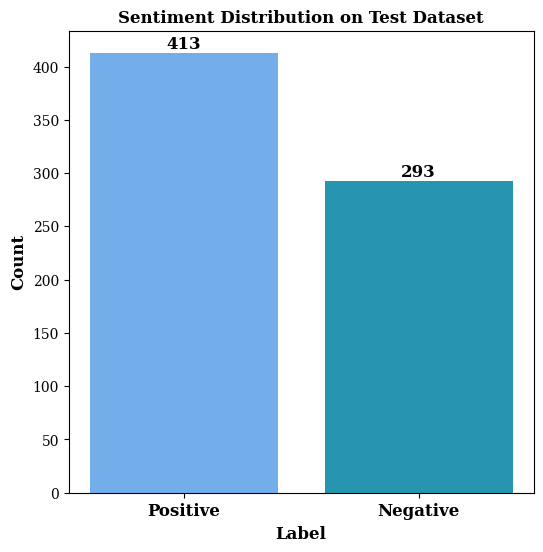

In [8]:
label_counts = test_data['sentiment'].value_counts()

# Define custom colors for the bars
custom_colors = ['#73aeea', '#2595b0']

# Define custom font dictionary for title and labels
font = {'family': 'Serif', 'weight': 'bold', 'size': 12}

plt.figure(figsize=(6, 6))

# Create bar plot with grid
bars = plt.bar(label_counts.index, label_counts.values, color=custom_colors)

# Set title and axis labels using custom fontdict
plt.title('Sentiment Distribution on Test Dataset', fontdict=font)
plt.xlabel('Label', fontdict=font)
plt.ylabel('Count', fontdict=font)

# Set custom font for ticks on both x and y axes
plt.xticks(label_counts.index, label_counts.index, fontdict=font)
plt.yticks(fontname='Serif', fontsize=10)

# Adding annotations (count values) on top of each bar
for bar, count in zip(bars, label_counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(count),
             ha='center', va='bottom', fontdict=font)

plt.show()

Preprocess the dataset

In [9]:
# 1. TEXT CLEANING FUNCTION
def clean_text(text):
    text = str(text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Remove mentions
    text = re.sub(r'@\w+', '', text)

    # Remove hashtag symbol only
    text = re.sub(r'#', '', text)

    # Remove emojis
    text = emoji.replace_emoji(text, replace='')

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text


# 2. DROP MISSING VALUES
train_data = train_data.dropna(subset=["short_description", "sentiment"])
val_data = val_data.dropna(subset=["short_description", "sentiment"])
test_data = test_data.dropna(subset=["short_description", "sentiment"])


# 3. KEEP ONLY POSITIVE & NEGATIVE
train_data = train_data[train_data["sentiment"].isin(["Positive", "Negative"])]
val_data = val_data[val_data["sentiment"].isin(["Positive", "Negative"])]
test_data = test_data[test_data["sentiment"].isin(["Positive", "Negative"])]


# 4. MAP LABELS
label_map = {
    "Negative": 0,
    "Positive": 1
}

train_data["sentiment"] = train_data["sentiment"].map(label_map)
val_data["sentiment"] = val_data["sentiment"].map(label_map)
test_data["sentiment"] = test_data["sentiment"].map(label_map)


# 5. CLEAN TEXT
train_data["short_description"] = train_data["short_description"].apply(clean_text)
val_data["short_description"] = val_data["short_description"].apply(clean_text)
test_data["short_description"] = test_data["short_description"].apply(clean_text)


# 6. RESET INDEX
train_data = train_data.reset_index(drop=True)
val_data = val_data.reset_index(drop=True)
test_data = test_data.reset_index(drop=True)


# 7. SAVE CLEANED FILES
train_data.to_csv("train_clean.csv", index=False)
val_data.to_csv("validation_clean.csv", index=False)
test_data.to_csv("test_clean.csv", index=False)

print("Binary preprocessing completed successfully!")

Binary preprocessing completed successfully!


Custom Dataset Class

In [10]:
class BanglaPoliticalSentimentDataset(Dataset):
    def __init__(self, data, tokenizer, max_length=512):
        self.data = data
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        content = self.data.iloc[idx]['short_description']
        label = self.data.iloc[idx]['sentiment']  # FIXED

        inputs = self.tokenizer(
            content,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            return_attention_mask=True,
            return_tensors='pt',
            truncation=True
        )

        return {
            'input_ids': inputs['input_ids'].squeeze(0),
            'attention_mask': inputs['attention_mask'].squeeze(0),
            'labels': torch.tensor(label, dtype=torch.long)  # MUST be "labels"
        }

In [11]:
!pip install git+https://github.com/csebuetnlp/normalizer
!pip install transformers[sentencepiece]
!pip install torch
!pip install accelerate -U

  Cloning https://github.com/csebuetnlp/normalizer to /tmp/pip-req-build-mysqysvd
  Running command git clone --filter=blob:none --quiet https://github.com/csebuetnlp/normalizer /tmp/pip-req-build-mysqysvd
  Resolved https://github.com/csebuetnlp/normalizer to commit d405944dde5ceeacb7c2fd3245ae2a9dea5f35c9
  Preparing metadata (setup.py) ... done


BanglaBERT model and its tokenizer

In [12]:
# Model loading
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from torch.optim import AdamW
from normalizer import normalize # pip install git+https://github.com/csebuetnlp/normalizer
num_classes = 2  #number of classes in our dataset

model_name = "csebuetnlp/banglabert"
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_classes)
tokenizer = AutoTokenizer.from_pretrained(model_name)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: csebuetnlp/banglabert
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
electra.embeddings.position_ids                   | UNEXPECTED | 
classifier.dense.bias                             | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoi

In [13]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

ElectraForSequenceClassification(
  (electra): ElectraModel(
    (embeddings): ElectraEmbeddings(
      (word_embeddings): Embedding(32000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): ElectraEncoder(
      (layer): ModuleList(
        (0-11): 12 x ElectraLayer(
          (attention): ElectraAttention(
            (self): ElectraSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): ElectraSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): L

Apply normalization to the datasets

In [14]:
# Apply normalization to the datasets
train_data['short_description'] = train_data['short_description'].apply(normalize)
test_data['short_description'] = test_data['short_description'].apply(normalize)
val_data['short_description'] = val_data['short_description'].apply(normalize)

Custom dataset and dataloader

In [15]:
# Define custom datasets
train_dataset = BanglaPoliticalSentimentDataset(train_data, tokenizer)
val_dataset = BanglaPoliticalSentimentDataset(val_data, tokenizer)
test_dataset = BanglaPoliticalSentimentDataset(test_data, tokenizer)

# Define data loaders
train_loader = DataLoader(train_dataset, batch_size=6, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=6, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=6, shuffle=False)

Train Dataset Encoding Printing

In [16]:
first_batch = True

for batch in train_loader:
    # Move tensors to device
    inputs = {key: value.to(device) for key, value in batch.items()}

    # Extract first example
    input_ids = inputs['input_ids'][0]
    attention_mask = inputs['attention_mask'][0]
    labels = inputs['labels'][0]   # FIXED (was 'label')

    print("Input IDs:", input_ids)
    print("Attention Mask:", attention_mask)
    print("Label:", labels)

    break

Input IDs: tensor([    2,  3243,  7969,  7306,  7982, 12255,  4660, 19807,  2150,    16,
         2712,  1004,  1650, 12017,  1198,  7017,   942,  4230,  2322,   896,
          205,   997,  3449,    12,  1457,  4090,    13,  4688,   788, 14662,
        29295,  2287,  4811,  3243, 18315,  1256,  1615, 18995,    17,  5561,
          219, 12930,  3180,  1541,  1228,   954,   217,   917,  1071,   205,
        19807,  1071,    16,    11,  1319,   990,   788,  4330,  1041,  1289,
         1087,    16,  8708,   788,  4330,  1041,   205,  1424,  7017,   942,
         4230,  2322,   205,  1650, 12017,  1031,  1631,  1004,   815,  1078,
         6468,  1052,   205, 14882,   824,  1232,   205,   917,  1505,  1817,
         1140,   809,  8005,   824,  1301,    16,  3572,   824,  4518,   205,
           11,     3,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,    

Optimizer and Loss Function

In [17]:
import torch.optim as optim
learning_rate = 2e-5
# Define the optimizer
optimizer = optim.AdamW(model.parameters(), lr=learning_rate)
criterion = torch.nn.CrossEntropyLoss()

Training the model

In [ ]:
num_epochs = 20
gradient_accumulation_steps = 16

for epoch in range(num_epochs):
    start_time = time.time()
    model.train()
    total_loss = 0
    optimizer.zero_grad()

    for batch_idx, batch in enumerate(tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}', leave=False)):

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)   # FIXED

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels      # IMPORTANT
        )

        loss = outputs.loss
        total_loss += loss.item()

        loss = loss / gradient_accumulation_steps
        loss.backward()

        if (batch_idx + 1) % gradient_accumulation_steps == 0:
            optimizer.step()
            optimizer.zero_grad()

    avg_train_loss = total_loss / len(train_loader)
    print(f'Epoch {epoch+1}/{num_epochs} - Train Loss: {avg_train_loss:.4f}')

    # ===== VALIDATION =====
    model.eval()
    val_preds = []
    val_labels = []

    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Validation", leave=False):

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)   # FIXED

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            logits = outputs.logits
            preds = torch.argmax(logits, dim=1)

            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    val_accuracy = accuracy_score(val_labels, val_preds)
    print(f'Validation Accuracy: {val_accuracy:.4f}')

    epoch_time = time.time() - start_time
    print(f"Epoch completed in {epoch_time//60:.0f}m {epoch_time%60:.0f}s")

Testing the model

In [21]:
test_preds = []
test_labels = []
test_probs = []  # Store predicted probabilities

with torch.no_grad():
    for batch in tqdm(test_loader, desc='Testing'):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        # Assuming our model directly outputs logits
        probabilities = torch.softmax(outputs.logits, dim=1)  # Softmax to get probabilities
        _, predicted = torch.max(outputs.logits, 1)

        test_preds.extend(predicted.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())
        test_probs.extend(probabilities.cpu().numpy())  # Append predicted probabilities

test_accuracy = accuracy_score(test_labels, test_preds)
test_precision = precision_score(test_labels, test_preds, average='macro')
test_recall = recall_score(test_labels, test_preds, average='macro')
test_f1 = f1_score(test_labels, test_preds, average='macro')

Testing: 100%|██████████| 118/118 [00:23<00:00,  4.98it/s]


In [22]:
print(test_preds)
print(test_labels)

[np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1)

Printing the evaluation metric results

In [23]:
print(f'Test Accuracy: {test_accuracy}')
print(f'Test Precision: {test_precision}')
print(f'Test Recall: {test_recall}')
print(f'Test F1 Score: {test_f1}')

Test Accuracy: 0.8711048158640227
Test Precision: 0.8716700645599729
Test Recall: 0.8615681478237156
Test F1 Score: 0.8655904867705607


Confusion Matrix of Political_Sentiment_Analysis

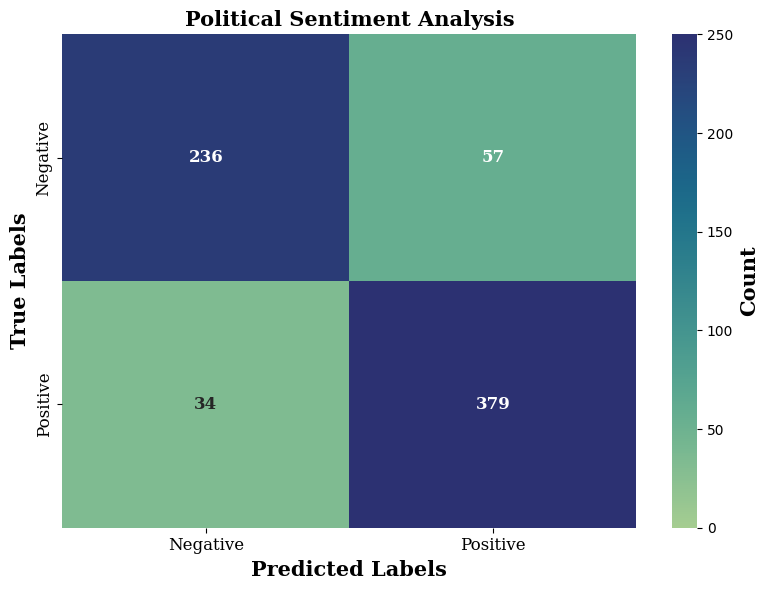

In [25]:
# Generate confusion matrix
conf_matrix = confusion_matrix(test_labels, test_preds)

# Plot confusion matrix
plt.figure(figsize=(8,6))
# Define the custom palette
custom_palette = sns.color_palette("crest", as_cmap=True)# Modify the number based on number of classes in the dataset
# Define custom font dictionary for title and labels
font = {'family': 'Serif', 'weight': 'bold', 'size': 15}

# Create heatmap with annotations and colormap
heatmap = sns.heatmap(conf_matrix, annot=True, fmt='d', cmap=custom_palette,vmin = 0,vmax = 250,
                      xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'],annot_kws={"family": "Serif",'weight': 'bold', 'size': 12})

# Set x and y labels with the custom font dictionary
heatmap.set_xlabel('Predicted Labels', fontdict=font)
heatmap.set_ylabel('True Labels', fontdict=font)
heatmap.set_title('Political Sentiment Analysis', fontdict=font)

# Set font properties for tick labels on both axes
heatmap.set_xticklabels(heatmap.get_xticklabels(), fontname='Serif', fontsize=12)
heatmap.set_yticklabels(heatmap.get_yticklabels(), fontname='Serif', fontsize=12)

# Create a color bar to indicate the scale
cbar = heatmap.collections[0].colorbar
cbar.set_label('Count', fontdict=font)
cbar.ax.tick_params(labelsize=10)
# Adjust layout to prevent cropping
plt.tight_layout()
plt.show()


Store predicted results to a csv file

In [26]:
# Combine the lists into a DataFrame
data = {'Content': test_data['short_description'],
        'True_Labels': test_data['sentiment'],
        'Predicted_Labels': test_preds}
df = pd.DataFrame(data)

# Save the DataFrame to a CSV file
df.to_csv('banglabert_predicted_results.csv', index=False)

save and load model, tokenizer, and classifier

In [27]:
# Save the model
model.save_pretrained('Bangla_political_Text_BanglaBERT_Model.pt')

# Save the tokenizer
tokenizer.save_pretrained('Bangla_political_Text_BanglaBERT_Tokenizer.json')
# load the model
model.from_pretrained('Bangla_political_Text_BanglaBERT_Model.pt')

# load the tokenizer
tokenizer.from_pretrained('Bangla_political_Text_BanglaBERT_Tokenizer.json')


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertTokenizer(name_or_path='Bangla_political_Text_BanglaBERT_Tokenizer.json', vocab_size=32000, model_max_length=1000000000000000019884624838656, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	4: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)